# Discriminatory and Feature Importance Plot

**This notebook presents performance metrics for a gradient boosted survival model predicting survival probability from time of first-line treatment for metastatic colorectal cancer. Specifically, it visualizes the model's time-dependent AUC on the test set and displays feature importance rankings.**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import cm

In [2]:
# Import CSV files 

gbm_auc_180d_df = pd.read_csv('../outputs/gbm_auc_180d_df.csv')

gbm_auc_over5_df = pd.read_csv('../outputs/gbm_auc_over5_df.csv', index_col = 0)

coefficients_gbm = pd.read_csv('../outputs/gbm_feature_importance.csv')

In [3]:
# Dataframe of average coefficient for variables for GBM
top_coef = (
    coefficients_gbm
    .groupby('variable')['coefficient'].mean()
    .to_frame()
    .sort_values(by = 'coefficient', ascending = False)
    .reset_index()
)

In [4]:
top_coef.head(20)

,variable,coefficient
0,num__age,0.122455
1,num__albumin,0.118395
2,num__cea,0.068700
3,num__alp,0.060076
4,num__days_met_to_treatment,0.053347
5,num__wbc,0.046409
6,num__chloride,0.040405
7,num__alp_max,0.039913
8,num__ecog_index,0.032925
9,num__albumin_min,0.022791


In [5]:
# Processing names of variables for plot 
top_coef.at[0, 'variable'] = 'Age'
top_coef.at[1, 'variable'] = 'Albumin'
top_coef.at[2, 'variable'] = 'CEA'
top_coef.at[3, 'variable'] = 'ALP'
top_coef.at[4, 'variable'] = 'Time to treatment'
top_coef.at[5, 'variable'] = 'WBC'
top_coef.at[6, 'variable'] = 'Chloride'
top_coef.at[7, 'variable'] = 'ALP, max'
top_coef.at[8, 'variable'] = 'ECOG'
top_coef.at[9, 'variable'] = 'Albumin, min'
top_coef.at[10, 'variable'] = 'Change in weight'
top_coef.at[11, 'variable'] = 'BMI'
top_coef.at[12, 'variable'] = 'Hemoglobin'
top_coef.at[13, 'variable'] = 'CEA, max'
top_coef.at[14, 'variable'] = 'dMMR/MSI-H status'

In [6]:
top_coef = top_coef.iloc[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], :]

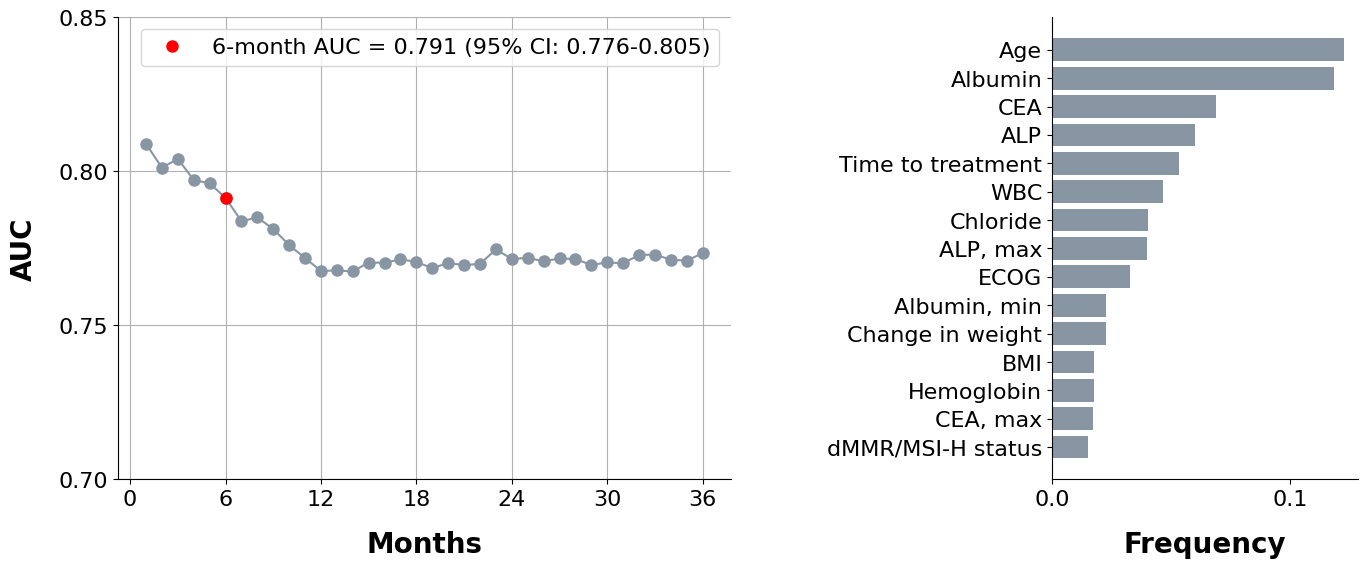

In [7]:
fig = plt.figure()

fig.set_figheight(6)
fig.set_figwidth(16)

spec = gridspec.GridSpec(ncols = 2, nrows = 1, width_ratios = [2, 1], wspace = 0.70)

# Discriminatory performance plot
times = np.arange(30, 1095, 30)

# Define timepoints and values
months_6 = 6
months_12 = 12
auc_6m = gbm_auc_over5_df['time_180'].iloc[0]   
auc_6m_lower_ci = gbm_auc_180d_df['auc_180d_test_lower'].iloc[0]
auc_6m_upper_ci = gbm_auc_180d_df['auc_180d_test_upper'].iloc[0]
#auc_12m = gbm_auc_over5_df['time_360'].iloc[0]  

# Create axis
ax0 = fig.add_subplot(spec[0])

# Plot AUC curve
ax0.plot(times/30, gbm_auc_over5_df.loc['gbm'].values[0:36], 'o-', color='#8896A4', markersize = 8)  

# Annotated points
ax0.plot(months_6, auc_6m, 'o', color='red', markersize = 8, label=f'6-month AUC = {auc_6m:.3f} (95% CI: {auc_6m_lower_ci:.3f}-{auc_6m_upper_ci:.3f})')
#ax0.plot(months_12, auc_12m, 'o', color='green', markersize = 8, label=f'12-month AUC = {auc_12m:.3f}')
ax0.legend(loc='upper right', fontsize=16)

# Axis formatting
ax0.set_xticks(np.arange(0, 37, 6))
ax0.set_yticks(np.arange(0.70, 0.85, 0.05))
ax0.tick_params(axis='both', which='major', labelsize=16)
#ax0.set_title('Discriminatory performance of GBM \n on test data', weight='bold', size=20, pad=20)
ax0.set_xlabel('Months', weight = 'bold', labelpad=15, size=20)
ax0.set_ylabel('AUC', weight = 'bold', labelpad=15, size=20)
ax0.grid(True)

# Remove top and right spines
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

# GBM feature importance plot
ax1 = fig.add_subplot(spec[1])

ax1.barh(top_coef['variable'], top_coef['coefficient'], color = '#8896A4')
ax1.set_yticks(top_coef['variable'])
ax1.invert_yaxis()

ax1.set_xticks(np.arange(0, 0.2, 0.1))
ax1.tick_params(axis = 'both', which = 'major', labelsize = 16)

#ax1.set_title('Frequency of features \n in GBM', weight = 'bold', size = 20, pad = 20)
ax1.set_xlabel('Frequency', weight = 'bold', labelpad = 15, size = 20)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/auc_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()